In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [2]:
data=loadmat('cluster_dataset.mat')

In [3]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

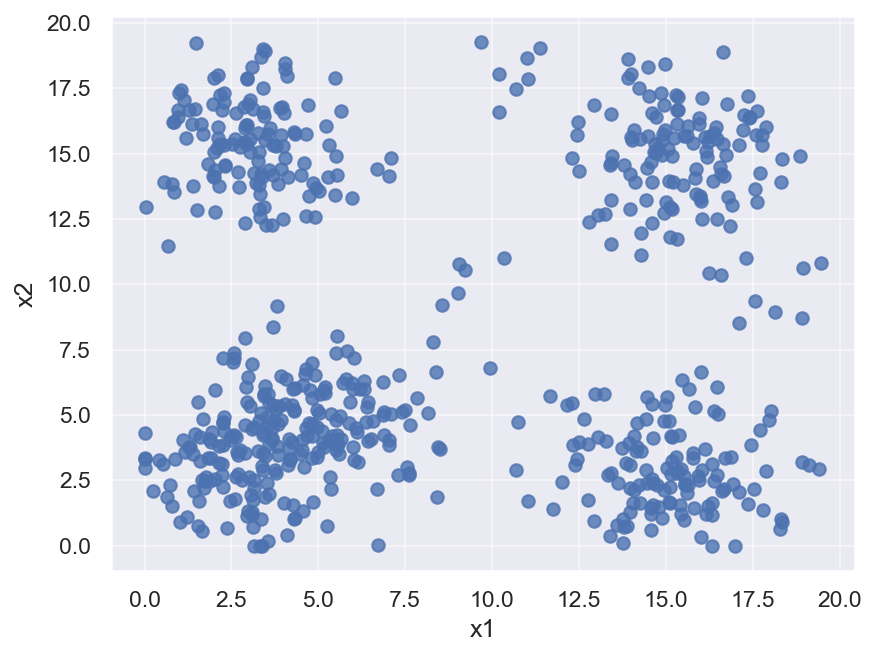

In [4]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [5]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 3

In [6]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    idx = random.sample(range(len(X)), k)
    centers = [X[i] for i in idx]
    
    return centers

In [7]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    distance= np.sqrt(np.sum((v1 - v2)**2))

    return distance

In [8]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
   assignment = {i: [] for i in range(len(centers))}
   for x in X:
        dists = [distance(x, center) for center in centers]
        cluster_idx = np.argmin(dists)
        assignment[cluster_idx].append(x)
   return assignment

In [9]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    cost = 0
    total_samples = 0
    for k in assignment:
        cluster = assignment[k]
        center = centers[k]
        for x in cluster:
            cost += distance(x, center)
        total_samples += len(cluster)
    
    return cost

In [10]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    new_centers = []
    stop = True  # 标记：中心没变化就True，变化了就False
    for k in assignment:
        cluster = np.array(assignment[k])
        new_center = np.mean(cluster, axis=0)
        new_centers.append(new_center)
        if not np.allclose(new_center, centers[k]):
            stop = False
    
    return new_centers, stop

In [11]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [12]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    centers = init_centers(X, k)
    stop = False
    epoch = 0
    while not stop and epoch < max_epoch:
        epoch += 1
        assignment = cluster_assignment(X, centers)
        centers, stop = center_update(assignment, centers)
        if plot:
            plot_clustering(assignment, centers, epoch)
    cost = cost_function(assignment, centers)
    
    return assignment, cost

In [13]:
max_epoch = 200 

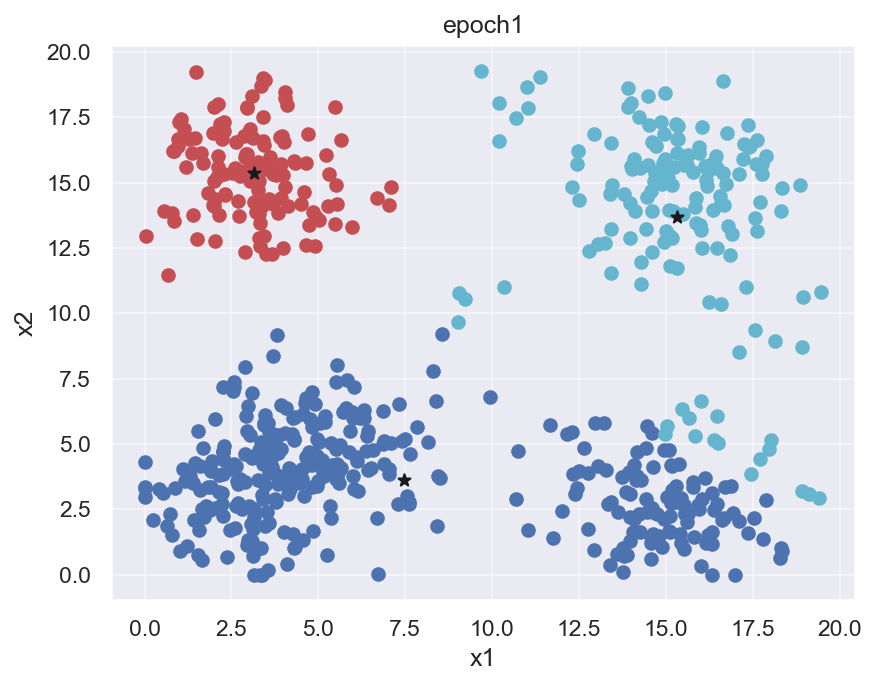

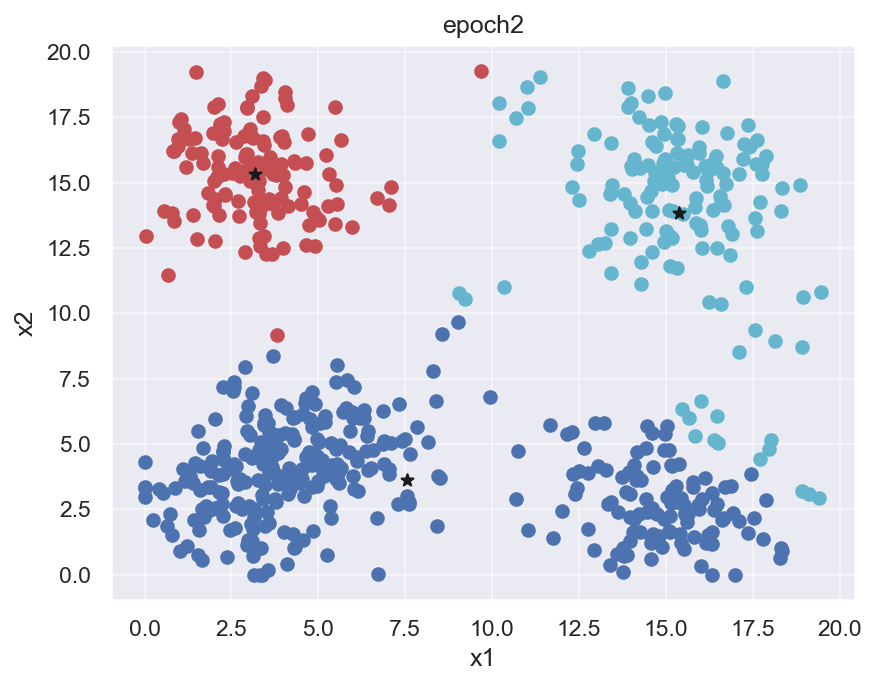

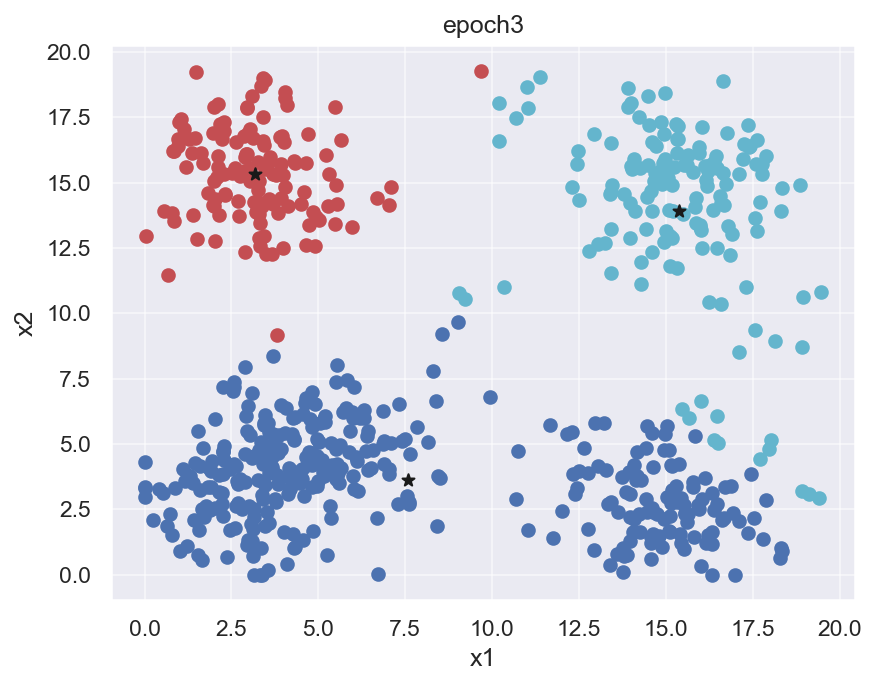

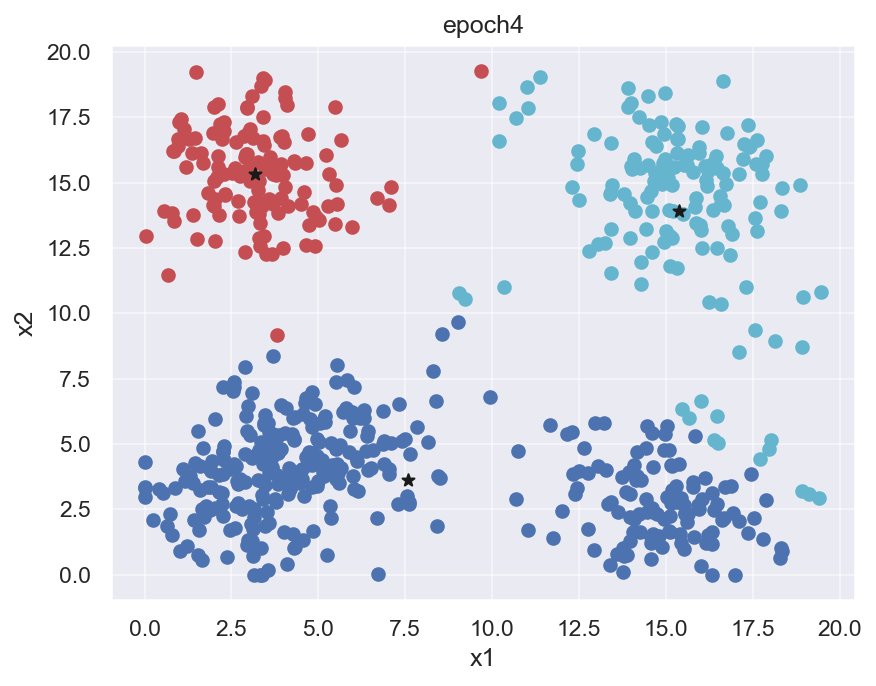

In [14]:
assignment, _ = kmeans(X, k, max_epoch)

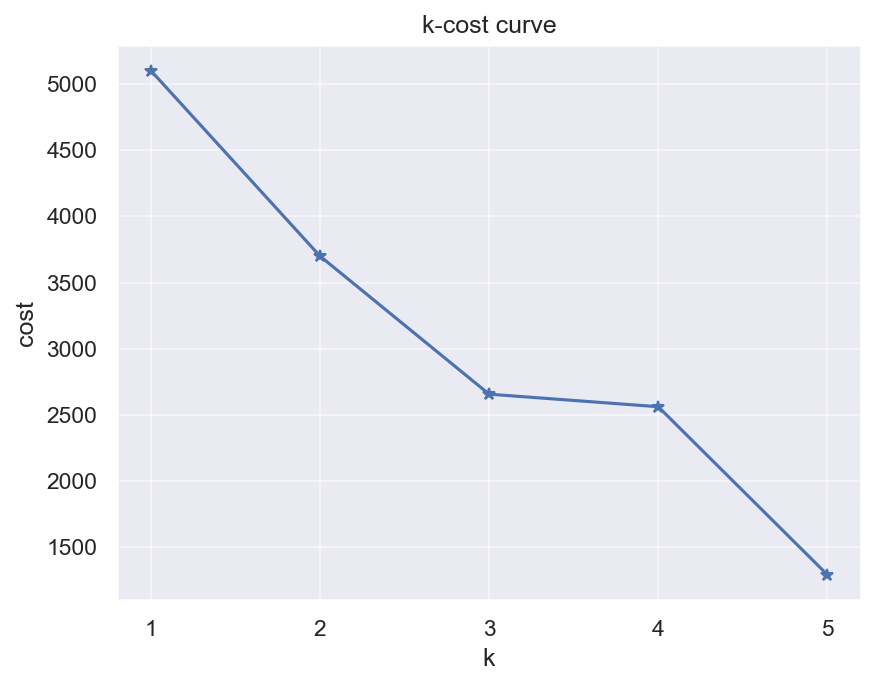

In [15]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()